In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

os.getcwd()

/kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/car data.csv
/kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/car details v4.csv
/kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/CAR DETAILS FROM CAR DEKHO.csv
/kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/Car details v3.csv


'/kaggle/working'

## Load Dataset

In [3]:
vechile_df = pd.read_csv('../input/datasets/nehalbirla/vehicle-dataset-from-cardekho/car data.csv')
vechile_df.shape

(301, 9)

In [4]:
df = vechile_df.copy()
df.head(10).style.background_gradient(cmap="Purples_r")

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.350000,5.590000,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.750000,9.540000,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.250000,9.850000,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.850000,4.150000,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.600000,6.870000,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.250000,9.830000,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.750000,8.120000,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.500000,8.610000,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.750000,8.890000,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.450000,8.920000,42367,Diesel,Dealer,Manual,0


## Basic Information about dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [7]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

## Data Preprocessing

In [8]:
df["Age"] = 2020 - df["Year"]
df.drop("Year", axis=1, inplace=True)

In [9]:
df.columns

Index(['Car_Name', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner', 'Age'],
      dtype='object')

In [10]:
df.rename(columns = {
    'Selling_Price':'Selling_Price(lacs)',
    'Present_Price':'Present_Price(lacs)',
    'Owner':'Past_Owners'},
    inplace = True
)

## EDA

Uni-Variate Analysis

In [11]:
df.columns

Index(['Car_Name', 'Selling_Price(lacs)', 'Present_Price(lacs)', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Past_Owners', 'Age'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Car_Name             301 non-null    object 
 1   Selling_Price(lacs)  301 non-null    float64
 2   Present_Price(lacs)  301 non-null    float64
 3   Kms_Driven           301 non-null    int64  
 4   Fuel_Type            301 non-null    object 
 5   Seller_Type          301 non-null    object 
 6   Transmission         301 non-null    object 
 7   Past_Owners          301 non-null    int64  
 8   Age                  301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


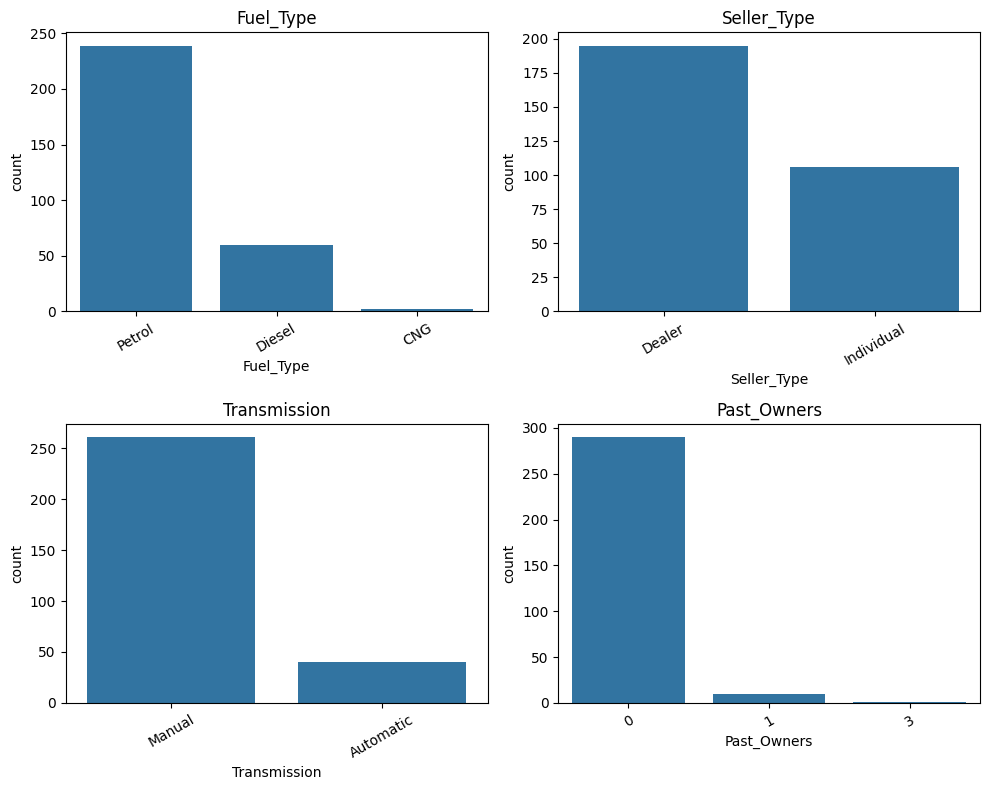

In [13]:
cat_cols = ['Fuel_Type', 'Seller_Type', 'Transmission', 'Past_Owners']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(ax=axes[i], x=col, data=df)
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

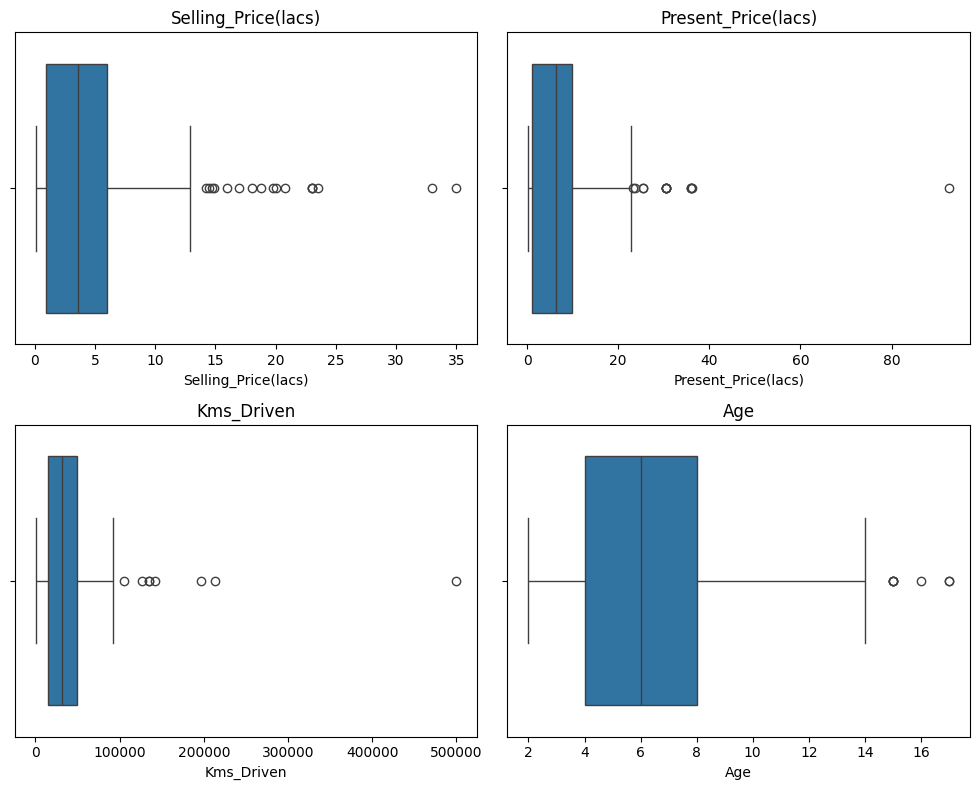

In [14]:
num_cols = ['Selling_Price(lacs)', 'Present_Price(lacs)', 'Kms_Driven', 'Age']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(ax=axes[i], x=col, data=df)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [15]:
df[df['Present_Price(lacs)'] > df['Present_Price(lacs)'].quantile(0.99)]

,Car_Name,Selling_Price(lacs),Present_Price(lacs),Kms_Driven,Fuel_Type,Seller_Type,Transmission,Past_Owners,Age
64,fortuner,33.0,36.23,6000,Diesel,Dealer,Automatic,0,3
86,land cruiser,35.0,92.60,78000,Diesel,Dealer,Manual,0,10


In [16]:
df[df['Selling_Price(lacs)'] > df['Selling_Price(lacs)'].quantile(0.99)]

,Car_Name,Selling_Price(lacs),Present_Price(lacs),Kms_Driven,Fuel_Type,Seller_Type,Transmission,Past_Owners,Age
63,fortuner,23.5,35.96,47000,Diesel,Dealer,Automatic,0,5
64,fortuner,33.0,36.23,6000,Diesel,Dealer,Automatic,0,3
86,land cruiser,35.0,92.60,78000,Diesel,Dealer,Manual,0,10


In [17]:
df[df['Kms_Driven'] > df['Kms_Driven'].quantile(0.99)]

,Car_Name,Selling_Price(lacs),Present_Price(lacs),Kms_Driven,Fuel_Type,Seller_Type,Transmission,Past_Owners,Age
84,innova,3.49,13.46,197176,Diesel,Dealer,Manual,0,15
179,Honda Karizma,0.31,1.05,213000,Petrol,Individual,Manual,0,10
196,Activa 3g,0.17,0.52,500000,Petrol,Individual,Automatic,0,12


Bi-Variate Analysis

In [18]:
df.corr(numeric_only=True).style.background_gradient(cmap="magma")

,Selling_Price(lacs),Present_Price(lacs),Kms_Driven,Past_Owners,Age
Selling_Price(lacs),1.000000,0.878983,0.029187,-0.088344,-0.236141
Present_Price(lacs),0.878983,1.000000,0.203647,0.008057,0.047584
Kms_Driven,0.029187,0.203647,1.000000,0.089216,0.524342
Past_Owners,-0.088344,0.008057,0.089216,1.000000,0.182104
Age,-0.236141,0.047584,0.524342,0.182104,1.000000


<Axes: >

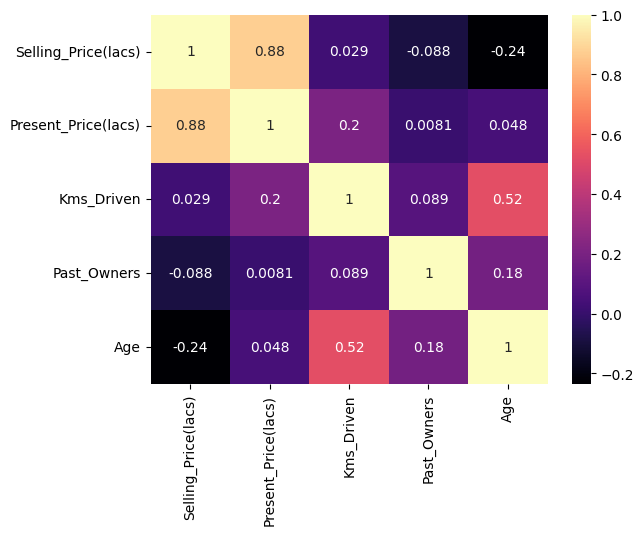

In [19]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="magma")

In [20]:
df.pivot_table(values='Selling_Price(lacs)', index = 'Seller_Type', columns= 'Fuel_Type')

Fuel_Type,CNG,Diesel,Petrol
Seller_Type,,,
Dealer,3.1,10.181525,5.252388
Individual,NaN,16.000000,0.726857


In [21]:
df.drop('Car_Name',axis= 1, inplace = True)

In [22]:
df.Fuel_Type.value_counts(), df.Seller_Type.value_counts(), df.Transmission.value_counts()

(Fuel_Type
 Petrol    239
 Diesel     60
 CNG         2
 Name: count, dtype: int64,
 Seller_Type
 Dealer        195
 Individual    106
 Name: count, dtype: int64,
 Transmission
 Manual       261
 Automatic     40
 Name: count, dtype: int64)

## Train Test Split

In [23]:
y = df['Selling_Price(lacs)']
X = df.drop('Selling_Price(lacs)', axis=1)

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((240, 7), (61, 7), (240,), (61,))

## Training-Based Preprocessing

In [25]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 240 entries, 102 to 37
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Present_Price(lacs)  240 non-null    float64
 1   Kms_Driven           240 non-null    int64  
 2   Fuel_Type            240 non-null    object 
 3   Seller_Type          240 non-null    object 
 4   Transmission         240 non-null    object 
 5   Past_Owners          240 non-null    int64  
 6   Age                  240 non-null    int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 15.0+ KB


In [26]:
X_train.shape, X_test.shape

((240, 7), (61, 7))

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']
numeric_cols = ['Present_Price(lacs)', 'Kms_Driven', 'Age', 'Past_Owners']

preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)
X_train.shape, X_test.shape

((240, 8), (61, 8))

In [28]:
feature_names = preprocessor.get_feature_names_out()
print(feature_names)

['cat__Fuel_Type_Diesel' 'cat__Fuel_Type_Petrol'
 'cat__Seller_Type_Individual' 'cat__Transmission_Manual'
 'num__Present_Price(lacs)' 'num__Kms_Driven' 'num__Age'
 'num__Past_Owners']


## Model Building & Evaluation

Applying regression models ->  
Linear Regression  
Ridge Regression  
Lasso Regression  
Random Forest Regression  
Gradient Boosting regression

In [29]:
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

R2_train = []
R2_test = []
CV = []
Model = []

def car_prediction_model(model, model_name):
    # Training model
    model.fit(X_train, y_train)
    Model.append(model_name)

    passed = False
    # If GridSearchCV is used, extract best model
    if hasattr(model, "best_estimator_"):
        print("Best Parameters:", model.best_params_)
        print("Best CV Score:", round(model.best_score_, 2))
        CV.append(round(model.best_score_, 2))
        model = model.best_estimator_
        passed = True

    # R2 score of train set
    y_pred_train = model.predict(X_train)
    R2_train.append(round(r2_score(y_train, y_pred_train), 2))

    # R2 score of test set
    y_pred_test = model.predict(X_test)
    R2_test.append(round(r2_score(y_test, y_pred_test), 2))


    # Printing results
    print("Model: ", Model[-1])
    print("Train R2-Score: ", R2_train[-1])
    print("Test R2-Score: ", R2_test[-1])

    # Cross Validation Score
    if not passed:
        cross_val = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
        CV.append(round(cross_val.mean(), 2))
        print("CV Scores:", cross_val)
        print("CV Mean:", CV[-1])
        
    # Plotting Graphs 
    # Residual Plot of train data
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.histplot(ax=axes[0], x=(y_train - y_pred_train), kde=True)
    axes[0].set_title("Residual Distribution")
    axes[0].set_xlabel("Residuals")

    # Y_test vs Y_train scatter plot
    sns.scatterplot(ax=axes[1], x=y_test, y=y_pred_test)
    axes[1].set_title("Actual vs Predicted")
    axes[1].set_xlabel("Actual Price")
    axes[1].set_ylabel("Predicted Price")

    plt.tight_layout()
    plt.show()

Model:  LinearRegression.pkl
Train R2-Score:  0.88
Test R2-Score:  0.86
CV Scores: [0.89912189 0.89838688 0.82980069 0.81769076 0.76113925]
CV Mean: 0.84


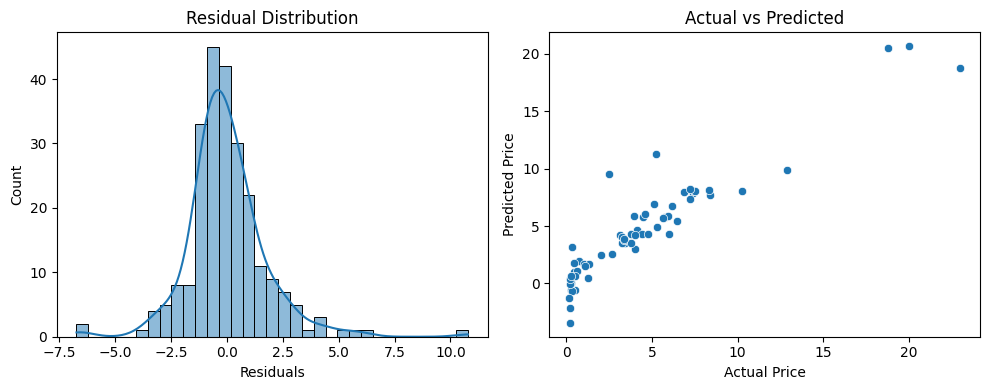

In [30]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
car_prediction_model(lr, "LinearRegression.pkl")

Best Parameters: {'alpha': np.float64(0.001)}
Best CV Score: 0.84
Model:  Ridge.pkl
Train R2-Score:  0.88
Test R2-Score:  0.86


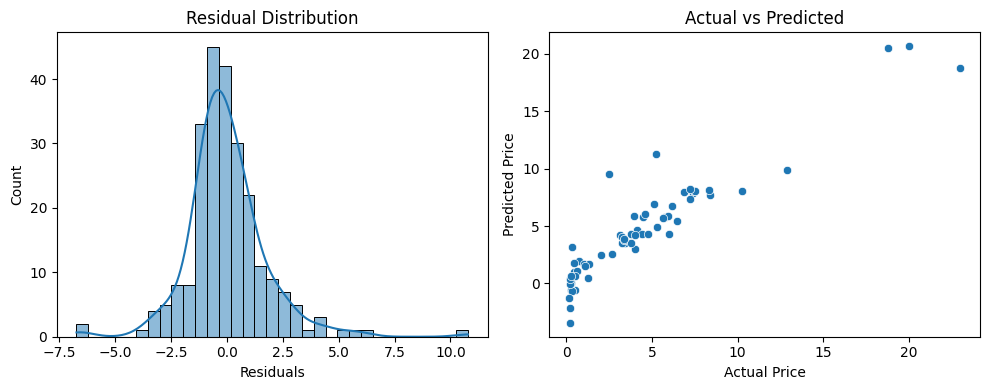

In [31]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

rg_gs = GridSearchCV(estimator=Ridge(), param_grid = dict(alpha=np.logspace(-3, 3, num=14)))
car_prediction_model(rg_gs, "Ridge.pkl")

Best Parameters: {'alpha': np.float64(0.001)}
Best CV Score: 0.84
Model:  Lasso.pkl
Train R2-Score:  0.88
Test R2-Score:  0.86


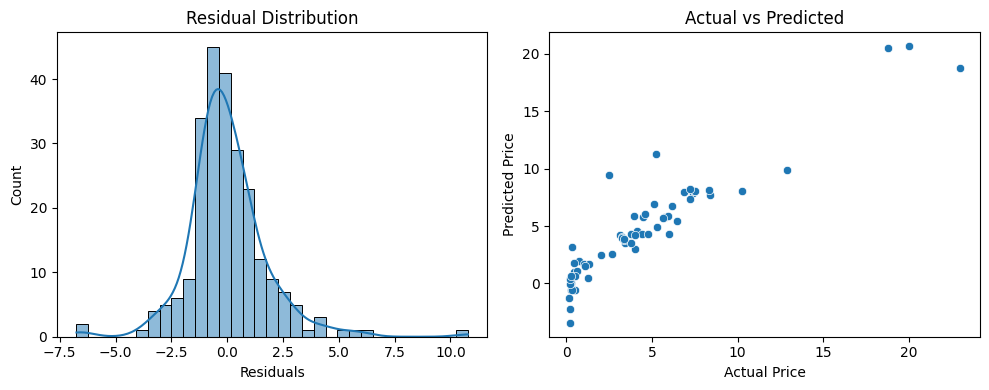

In [32]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

ls_gs = GridSearchCV(estimator=Lasso(), param_grid = dict(alpha=np.logspace(-3, 3, num=14)))
car_prediction_model(ls_gs, "Lasso.pkl")

Best Parameters: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score: 0.89
Model:  RandomForest.pkl
Train R2-Score:  0.99
Test R2-Score:  0.87


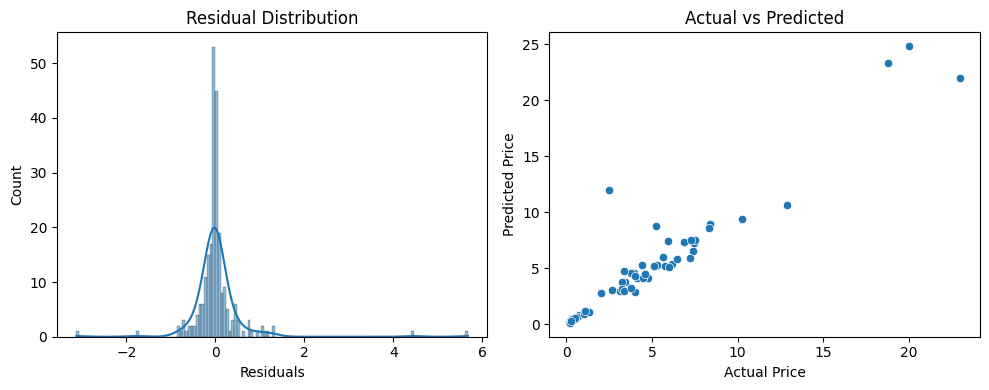

In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 8, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", None]
}
rf_gs = GridSearchCV(estimator=RandomForestRegressor(random_state=42), param_grid=params, scoring="r2", cv=5, n_jobs=-1)
car_prediction_model(rf_gs, "RandomForest.pkl")

In [34]:
results = pd.DataFrame({
    'Model': Model,
    'R Squared(Train)': R2_train,
    'R Squared(Test)': R2_test,
    'Cross Validation Score': CV
})

results = results.sort_values(
    by='R Squared(Test)',
    ascending=False
).reset_index(drop=True)

display(results)

,Model,R Squared(Train),R Squared(Test),Cross Validation Score
0,RandomForest.pkl,0.99,0.87,0.89
1,LinearRegression.pkl,0.88,0.86,0.84
2,Ridge.pkl,0.88,0.86,0.84
3,Lasso.pkl,0.88,0.86,0.84
